In [8]:
import pandas as pd

In [9]:
df = pd.read_parquet("data/plantvillage-image-text-pairs.parquet")

In [10]:
print(df.head(3))

                                               image             caption  \
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      Tomato healthy   
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...  Tomato Late blight   
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      Tomato healthy   

                                            captions  
0  [A vibrant green and healthy tomato leaf with ...  
1  [A tomato leaf showing dark brown lesions and ...  
2  [A vibrant green and healthy tomato leaf with ...  


In [11]:
df.head(3)

,image,caption,captions
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Tomato healthy,[A vibrant green and healthy tomato leaf with ...
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Tomato Late blight,[A tomato leaf showing dark brown lesions and ...
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Tomato healthy,[A vibrant green and healthy tomato leaf with ...


In [12]:
df.dtypes

image       object
caption     object
captions    object
dtype: object

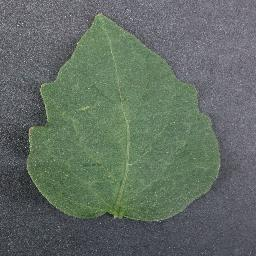

In [ ]:
from PIL import Image
import io

def display_image_from_row(row):
    image_bytes = row['image']['bytes']
    img = Image.open(io.BytesIO(image_bytes))
    display(img)

display_image_from_row(df.iloc[0])

In [7]:
df.iloc[0]['captions']

array(['A vibrant green and healthy tomato leaf with smooth, spotless surface.',
       'A healthy Solanum lycopersicum leaf, free of disease or pests, with a uniform green color.',
       'A fresh tomato leaf outdoors, glowing in sunlight with a smooth and unblemished surface.',
       'A clean and healthy tomato leaf image, perfect for comparison in plant health datasets.'],
      dtype=object)

In [19]:
print(df['caption'].unique())

['Tomato healthy' 'Tomato Late blight' 'Tomato mosaic virus'
 'Pepper bell healthy' 'Potato Early blight' 'Tomato Early blight'
 'Tomato YellowLeaf Curl Virus' 'Tomato Target Spot'
 'Pepper bell Bacterial spot' 'Tomato Septoria leaf spot'
 'Tomato Spider mites Two spotted spider mite' 'Tomato Bacterial spot'
 'Potato Late blight' 'Tomato Leaf Mold' 'Potato healthy']


In [18]:
import torch
from models.scold.model import LVL
from transformers import RobertaTokenizer
from PIL import Image
from torchvision import transforms

AttributeError: module 'sympy' has no attribute 'printing'

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Load model
model = LVL()
model.load_state_dict(torch.load("models/scold/model_fn.pt", map_location=device))
model.to(device)
model.eval()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\Andakara\AppData\Local\Temp\ipykernel_192056\2665840536.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe

LVL(
  (image_encoder): ImageEncoder(
    (swin): FeatureListNet(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
        (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (layers_0): SwinTransformerStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=128, out_features=384, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=128, out_features=128, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path1): Identity()
            (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=128, out_fe

In [ ]:
# Load tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def encode_text(texts):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        _, text_emb = model(None, inputs["input_ids"], inputs["attention_mask"])
    return text_emb.cpu().numpy()

def encode_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        image_emb, _ = model(image_tensor, None, None)
    return image_emb.cpu().numpy()

In [ ]:
from qdrant_client import QdrantClient
from qdrant_client.http import models

client = QdrantClient(url="http://localhost:6333")

In [ ]:
collection_name = "leaf_disease_collection"

if client.collection_exists(collection_name):
    client.delete_collection(collection_name)
client.create_collection(
    collection_name=collection_name,
    vectors_config=models.VectorParams(size=512, distance=models.Distance.COSINE),
)

In [ ]:
vectors = []
payloads = []

for doc in documents:
    text_vec = encode_text([doc["captions"]])[0]
    img_vec = encode_image(doc["image"])[0]

    vectors.append(text_vec)
    payloads.append({"type": "text", "text": doc["captions"]})

    vectors.append(img_vec)
    payloads.append({"type": "image", "path": doc["image"]})

client.upsert(
    collection_name="leaf_disease_collection",
    points=[
        models.PointStruct(id=i, vector=vectors[i], payload=payloads[i])
        for i in range(len(vectors))
    ]
)